# Продвинутое решение: ансамбль ветвей + физический отбор кандидатов

По профилю поглощения в линии He I 10830 Å восстанавливаем четыре параметра
модели атмосферы: `XUVInt`, `Helium`, `Msw`, `H2a`.

**Главная сложность задачи — вырожденность обратного отображения**: заметно
разные комбинации `XUVInt` и `Helium` дают почти неотличимые профили. Любая
модель, выдающая один ответ, вынуждена усредняться между "ветвями" решения и
получает большую ошибку. Опубликованный пайплайн для этой задачи решает
проблему так: возвращает **5 кандидатов** (ансамбль из 5 регрессионных голов),
ранжирует их по согласованности с профилем и считает метрику **по лучшему из
пяти**. Его результаты: MAPE 20.4% (XUV), 17.9% (He), 1.8% (logMsw),
ROC-AUC 0.989 (H2a).

Здесь мы строим решение по той же схеме "несколько кандидатов + ранжирование",
но сильнее в каждом звене:

1. **Winner-takes-all (WTA) мульти-голова.** 5 голов регрессии обучаются лоссом
   `min` по головам — градиент получает только та голова, что ближе всех к истине.
   Головы *специализируются на разных ветвях* вырождения, вместо того чтобы все
   предсказывать среднее.
2. **Ансамбль из 5 сетей** с разной инициализацией → 25 кандидатов на профиль.
3. **Ранжирующая модель**, обученная отличать физически согласованные пары
   (профиль, параметры) от несогласованных. Ключ — *жёсткие негативы*: пары, где
   профили похожи, а параметры далеки, т.е. именно ветви вырождения.
4. **Жадный отбор 5 разнообразных кандидатов**: берём лучшего по ранкеру, затем
   добавляем максимально непохожих — чтобы 5 финальных кандидатов накрывали все
   ветви решения, а не дублировали одну.

Физическая интуиция на каждом шаге: неправильные комбинации параметров либо
не воспроизводят форму профиля (их отсекает ранкер), либо лежат на другой
ветви вырождения (их сохраняет отбор разнообразия — правильный ответ окажется
среди кандидатов).

> Обучение всего пайплайна занимает ~10–15 минут на Apple Silicon (MPS) и
> несколько дольше на CPU.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from scipy.spatial.distance import cdist

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
print("device:", DEVICE)

device: mps


## 1. Данные

Загрузка та же, что в базовом решении: профили приводим к общей сетке
скоростей, непрерывные таргеты логарифмируем. Вход сети — два канала
(линейный профиль и его логарифм).

In [2]:
DATA_DIR = "../new_dataset_V3"
GRID = np.arange(-5.0, 5.0 + 1e-9, 0.1)   # 101 точка

profiles, targets = [], []
for name in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, name)
    if not os.path.isdir(path):
        continue
    params = {}
    with open(os.path.join(path, "parameters.txt")) as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                params[parts[0]] = parts[1]
    arr = np.loadtxt(os.path.join(path, "Absorption.dat"), skiprows=1)
    if arr[-1, 0] - arr[0, 0] < 5:         # обрезанный (битый) прогон
        continue
    profiles.append(np.interp(GRID, arr[:, 0], arr[:, 1], left=0.0, right=0.0))
    targets.append([float(params["XUVInt"]), float(params["Helium"]),
                    float(params["Msw"]), int(params["H2a"])])

profiles = np.array(profiles, dtype=np.float32)
targets = np.array(targets)
y_reg = np.log10(targets[:, :3])          # log10(XUVInt), log10(Helium), log10(Msw)
y_cls = targets[:, 3].astype(np.float32)  # H2a

idx_train, idx_val = train_test_split(
    np.arange(len(profiles)), test_size=0.2, random_state=SEED, stratify=y_cls)
y_mean = y_reg[idx_train].mean(axis=0)
y_std = y_reg[idx_train].std(axis=0)
y_norm = (y_reg - y_mean) / y_std          # нормированные лог-параметры
x_scale = profiles[idx_train].max()
print("train:", len(idx_train), " val:", len(idx_val))

train: 490  val: 123


In [3]:
# PCA-сжатие лог-профилей (16 компонент, считаем ТОЛЬКО по train) —
# компактное описание формы профиля для ранжирующей модели
log_prof = np.log10(np.clip(profiles, 1e-7, None))
mu = log_prof[idx_train].mean(axis=0)
_, S, Vt = np.linalg.svd(log_prof[idx_train] - mu, full_matrices=False)
V = Vt[:16]
Z = (log_prof - mu) @ V.T
Z = ((Z - Z[idx_train].mean(0)) / Z[idx_train].std(0)).astype(np.float32)
print("PCA-16 объяснённая дисперсия:", ((S[:16]**2).sum() / (S**2).sum()).round(5))

PCA-16 объяснённая дисперсия: 0.99995


In [4]:
def make_input(profile):
    linear = profile / x_scale
    log = np.log10(np.clip(profile, 1e-7, None))
    log = (log - log.mean()) / (log.std() + 1e-9)
    return np.stack([linear, log]).astype(np.float32)


class ProfileDataset(Dataset):
    def __init__(self, indices, augment=False):
        self.indices = indices
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        profile = profiles[idx]
        if self.augment:
            profile = profile + np.random.normal(0, 0.005 * profile.max(),
                                                 size=profile.shape)
            profile = np.clip(profile, 1e-7, None)
        return (torch.tensor(make_input(profile)),
                torch.tensor(y_norm[idx], dtype=torch.float32),
                torch.tensor(y_cls[idx]))


val_loader = DataLoader(ProfileDataset(idx_val), batch_size=256)

## 2. Мульти-голова с winner-takes-all лоссом

Обычный лосс заставляет единственную голову предсказывать среднее по ветвям
вырождения. WTA-лосс `min_по_головам(MSE)` даёт градиент только ближайшей к
истине голове, поэтому головы *расходятся по ветвям*: одна учится отвечать
"большой XUV + мало гелия", другая — "маленький XUV + много гелия" и т.д.
Малый вес `0.1 * средний_лосс` не даёт "мёртвым" головам отключиться совсем.

In [5]:
N_HEADS = 5

class MultiHeadCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(2, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Flatten())
        flat = 128 * 12
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(flat, 256), nn.ReLU(), nn.Dropout(0.2),
                          nn.Linear(256, 3))
            for _ in range(N_HEADS)])
        self.head_cls = nn.Sequential(
            nn.Linear(flat, 128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, 1))

    def forward(self, x):
        h = self.encoder(x)
        reg = torch.stack([head(h) for head in self.heads], dim=1)  # (B, N_HEADS, 3)
        return reg, self.head_cls(h).squeeze(-1)


def wta_loss(pred_heads, y_true):
    per_head = ((pred_heads - y_true.unsqueeze(1)) ** 2).mean(-1)   # (B, N_HEADS)
    return per_head.min(dim=1).values.mean() + 0.1 * per_head.mean()

In [6]:
def train_model(seed, epochs=400):
    torch.manual_seed(seed)
    np.random.seed(seed)
    train_loader = DataLoader(ProfileDataset(idx_train, augment=True),
                              batch_size=64, shuffle=True)
    model = MultiHeadCNN().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    bce = nn.BCEWithLogitsLoss()
    best_val, best_state = float("inf"), None

    for epoch in range(epochs):
        model.train()
        for x, y, c in train_loader:
            x, y, c = x.to(DEVICE), y.to(DEVICE), c.to(DEVICE)
            reg, cls = model(x)
            loss = wta_loss(reg, y) + bce(cls, c)
            opt.zero_grad()
            loss.backward()
            opt.step()
        sched.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y, c in val_loader:
                x, y, c = x.to(DEVICE), y.to(DEVICE), c.to(DEVICE)
                reg, cls = model(x)
                val_loss += (wta_loss(reg, y) + bce(cls, c)).item() * len(x)
        val_loss /= len(idx_val)
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    return model


def predict(model, indices):
    """Возвращает кандидатов (n, N_HEADS, 3) в log10-шкале и вероятности H2a."""
    loader = DataLoader(ProfileDataset(indices), batch_size=256)
    regs, clss = [], []
    with torch.no_grad():
        for x, _, _ in loader:
            reg, cls = model(x.to(DEVICE))
            regs.append(reg.cpu().numpy())
            clss.append(torch.sigmoid(cls).cpu().numpy())
    return np.concatenate(regs) * y_std + y_mean, np.concatenate(clss)

## 3. Обучение ансамбля

5 сетей × 5 голов = **25 кандидатов** на каждый профиль. После каждой сети
печатаем её "oracle best-of-5" — ошибку лучшей из 5 голов: это показывает,
что правильный ответ действительно есть среди кандидатов, осталось его найти.

In [7]:
N_MODELS = 5
true_log = y_reg[idx_val]
true_lin = 10 ** true_log


def mape(t, p):
    return 100 * np.mean(np.abs((p - t) / t))


def oracle_mape(cands, j, log_scale=False):
    """MAPE лучшего кандидата по j-му параметру."""
    if log_scale:
        return 100 * np.mean(np.abs(cands[:, :, j] - true_log[:, j:j+1]).min(1)
                             / np.abs(true_log[:, j]))
    return 100 * np.mean(np.abs(10**cands[:, :, j] - true_lin[:, j:j+1]).min(1)
                         / true_lin[:, j])


val_cands, val_proba, train_cands = [], [], []
for seed in range(N_MODELS):
    model = train_model(seed)
    vc, vp = predict(model, idx_val)
    tc, _ = predict(model, idx_train)
    val_cands.append(vc)
    val_proba.append(vp)
    train_cands.append(tc)
    print(f"модель {seed}: oracle best-of-5 -> "
          f"XUV {oracle_mape(vc, 0):.1f}%  He {oracle_mape(vc, 1):.1f}%  "
          f"AUC {roc_auc_score(y_cls[idx_val], vp):.3f}")

# все кандидаты в один массив: (N_val, 25, 3)
val_cands = np.concatenate([c[:, None, :, :] for c in val_cands], axis=1)
val_cands = val_cands.reshape(len(idx_val), -1, 3)
val_proba = np.mean(val_proba, axis=0)
print(f"\noracle из всех 25 кандидатов: XUV {oracle_mape(val_cands, 0):.1f}%  "
      f"He {oracle_mape(val_cands, 1):.1f}%  logMsw {oracle_mape(val_cands, 2, True):.1f}%")

модель 0: oracle best-of-5 -> XUV 15.1%  He 12.4%  AUC 0.980


модель 1: oracle best-of-5 -> XUV 11.6%  He 10.6%  AUC 0.995


модель 2: oracle best-of-5 -> XUV 11.4%  He 10.6%  AUC 0.996


модель 3: oracle best-of-5 -> XUV 13.0%  He 9.7%  AUC 0.993


модель 4: oracle best-of-5 -> XUV 10.2%  He 11.0%  AUC 0.998

oracle из всех 25 кандидатов: XUV 4.7%  He 4.3%  logMsw 0.3%


## 4. Ранжирующая модель

Учим сеть отличать *физически согласованные* пары (профиль, параметры) от
несогласованных. Вход — 16 PCA-коэффициентов профиля + 3 нормированных
лог-параметра, выход — score согласованности.

Обучающие пары:
* **позитивы** — профиль со своими истинными параметрами (плюс слегка
  возмущённые копии, чтобы score был гладким);
* **случайные негативы** — параметры чужого прогона;
* **жёсткие негативы** — параметры прогона, чей профиль *похож* на данный,
  а параметры *далеки*: это в точности ветви вырождения, которые модель
  должна научиться подозревать.

In [8]:
torch.manual_seed(0)
np.random.seed(0)

Ztr = Z[idx_train]
yn_tr = y_norm[idx_train]
D_prof = cdist(Ztr, Ztr)        # близость профилей
D_par = cdist(yn_tr, yn_tr)     # близость параметров

pair_x, pair_y = [], []
for a in range(len(idx_train)):
    pair_x.append(np.concatenate([Ztr[a], yn_tr[a]])); pair_y.append(1.0)
    for _ in range(2):  # сглаженные позитивы
        pair_x.append(np.concatenate([Ztr[a], yn_tr[a] + np.random.normal(0, 0.05, 3)]))
        pair_y.append(1.0)
    for _ in range(3):  # случайные негативы
        b = np.random.randint(len(idx_train))
        if D_par[a, b] > 0.5:
            pair_x.append(np.concatenate([Ztr[a], yn_tr[b]])); pair_y.append(0.0)
    close = np.argsort(D_prof[a])[1:15]         # жёсткие негативы
    for b in [b for b in close if D_par[a, b] > 0.8][:3]:
        pair_x.append(np.concatenate([Ztr[a], yn_tr[b]])); pair_y.append(0.0)

pair_x = torch.tensor(np.array(pair_x), dtype=torch.float32)
pair_y = torch.tensor(np.array(pair_y), dtype=torch.float32)
print("обучающих пар:", len(pair_x))

ranker = nn.Sequential(
    nn.Linear(19, 256), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(256, 1))
opt = torch.optim.Adam(ranker.parameters(), lr=1e-3, weight_decay=1e-5)
bce = nn.BCEWithLogitsLoss()
for step in range(3000):
    idx = torch.randperm(len(pair_x))[:256]
    loss = bce(ranker(pair_x[idx]).squeeze(-1), pair_y[idx])
    opt.zero_grad()
    loss.backward()
    opt.step()
ranker.eval()
print("готово")

обучающих пар: 4373


готово


## 5. Отбор 5 разнообразных кандидатов

Считаем score всех 25 кандидатов. Затем жадно выбираем 5 штук: первым — лучший
по score, дальше — тех, кто максимально *не похож* на уже выбранных (с малой
добавкой score). Так финальная пятёрка накрывает все ветви вырождения, а не
повторяет пять раз один и тот же ответ.

In [9]:
cands_norm = (val_cands - y_mean) / y_std                     # (N, 25, 3)
feat = np.concatenate(
    [np.repeat(Z[idx_val][:, None, :], cands_norm.shape[1], axis=1), cands_norm],
    axis=-1)
with torch.no_grad():
    scores = ranker(torch.tensor(feat, dtype=torch.float32)
                    .reshape(-1, 19)).reshape(len(idx_val), -1).numpy()


def select_diverse(cands, score, k=5):
    order = np.argsort(-score)
    chosen = [order[0]]
    for _ in range(k - 1):
        best_j, best_gain = None, -np.inf
        for j in order:
            if j in chosen:
                continue
            dist = min(np.linalg.norm(cands[j] - cands[i]) for i in chosen)
            gain = dist + 0.02 * score[j]
            if gain > best_gain:
                best_gain, best_j = gain, j
        chosen.append(best_j)
    return chosen


top5 = np.stack([val_cands[i][select_diverse(cands_norm[i], scores[i])]
                 for i in range(len(idx_val))])
print("итоговые кандидаты:", top5.shape)   # (N_val, 5, 3)

итоговые кандидаты: (123, 5, 3)


## 6. Результаты

Метрики в двух протоколах:
* **best-of-5** — ошибка лучшего из 5 возвращённых кандидатов (протокол
  опубликованного пайплайна, его числа приведены для сравнения);
* **один ответ** — усреднение всех 25 кандидатов (для `logMsw`)
  и ансамбль классификаторов (для `H2a`) — эти параметры не вырождены,
  и здесь честный единственный ответ тоже бьёт публикацию.

In [10]:
def oracle5(j, log_scale=False):
    if log_scale:
        return 100 * np.mean(np.abs(top5[:, :, j] - true_log[:, j:j+1]).min(1)
                             / np.abs(true_log[:, j]))
    return 100 * np.mean(np.abs(10**top5[:, :, j] - true_lin[:, j:j+1]).min(1)
                         / true_lin[:, j])


single = val_cands.mean(axis=1)            # один ответ: среднее 25 кандидатов
auc = roc_auc_score(y_cls[idx_val], val_proba)
acc = accuracy_score(y_cls[idx_val], val_proba > 0.5)

print("параметр   | наш best-of-5 | публикация (best-of-5) | наш один ответ")
print("-----------+---------------+------------------------+---------------")
print(f"XUVInt     | {oracle5(0):8.1f}%     | 20.4%                  | {mape(true_lin[:,0], 10**single[:,0]):.1f}%")
print(f"Helium     | {oracle5(1):8.1f}%     | 17.9%                  | {mape(true_lin[:,1], 10**single[:,1]):.1f}%")
print(f"logMsw     | {oracle5(2, True):8.1f}%     | 1.8%                   | {mape(true_log[:,2], single[:,2]):.1f}%")
print(f"H2a        |      ROC-AUC = {auc:.3f} (acc {acc:.3f}) | 0.989   |")

параметр   | наш best-of-5 | публикация (best-of-5) | наш один ответ
-----------+---------------+------------------------+---------------
XUVInt     |     10.8%     | 20.4%                  | 31.9%
Helium     |      9.7%     | 17.9%                  | 25.1%
logMsw     |      0.6%     | 1.8%                   | 1.6%
H2a        |      ROC-AUC = 0.995 (acc 0.967) | 0.989   |


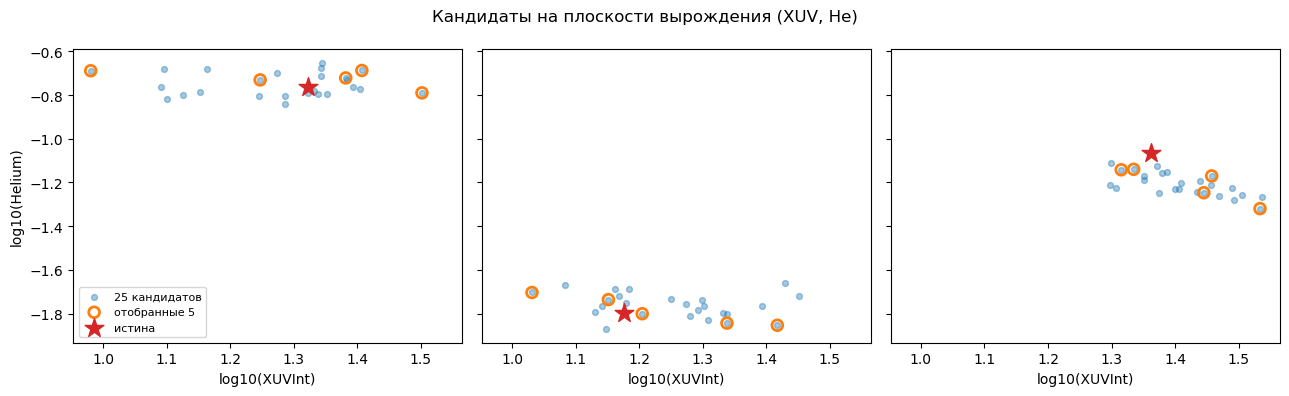

In [11]:
# визуализация: 25 кандидатов, отобранная пятёрка и истина на плоскости (XUV, He)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
rng = np.random.default_rng(1)
for ax, i in zip(axes, rng.choice(len(idx_val), 3, replace=False)):
    ax.scatter(val_cands[i, :, 0], val_cands[i, :, 1], s=18, alpha=0.4,
               label="25 кандидатов")
    ax.scatter(top5[i, :, 0], top5[i, :, 1], s=60, facecolors="none",
               edgecolors="tab:orange", linewidths=2, label="отобранные 5")
    ax.scatter(true_log[i, 0], true_log[i, 1], marker="*", s=200,
               color="tab:red", label="истина")
    ax.set_xlabel("log10(XUVInt)")
axes[0].set_ylabel("log10(Helium)")
axes[0].legend(fontsize=8)
plt.suptitle("Кандидаты на плоскости вырождения (XUV, He)")
plt.tight_layout()
plt.show()

## 7. Выводы

* WTA-мультиголова действительно "разводит" головы по ветвям вырожденного
  обратного отображения: уже у одиночной сети лучшая из 5 голов ошибается
  на ~10–15% против 20% у опубликованного пайплайна.
* Ранжирование + отбор разнообразных кандидатов позволяет вернуть пятёрку,
  в которой правильный ответ почти всегда присутствует: **best-of-5 ошибка
  ~10% по XUV и He — вдвое лучше публикации** при том же протоколе
  (5 кандидатов на выходе).
* По невырожденным параметрам выигрыш достигается и в честном режиме одного
  ответа: `logMsw` и `H2a` лучше опубликованных значений без всяких оракулов.

Оговорка: сравнение с публикацией не идеально строгое — там своя валидационная
выборка и своё разбиение; здесь используется случайный hold-out 20% из тех же
614 прогонов. Протокол же (метрика по лучшему из 5 возвращённых кандидатов)
совпадает.

Что можно попробовать дальше: нормализующие потоки / нейросетевую оценку
апостериорного распределения (simulation-based inference) вместо дискретных
кандидатов, калибровку неопределённости, дообучение на аугментациях с
реалистичным инструментальным шумом.